# Raport z laboratorium 2

# Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import binom, beta, norm, probplot, logistic, lognorm
from scipy.optimize import minimize

## Zadanie 1

In [27]:
def mle(X):
    return np.mean(X) / 5

In [28]:
ns = [20, 50, 100]
ps = np.arange(0.1, 1, 0.2)
num_runs = 10000

results = {}
for n in ns:
    for p in ps:
        ppb_values = []
        for _ in range(num_runs):
            X = binom.rvs(5, p, size=n)
            p_mle = mle(X)

            ppb = binom.pmf(3, 5, p_mle) + binom.pmf(4, 5, p_mle) + binom.pmf(5, 5, p_mle)

            ppb_values.append(ppb)
        results[n, p] = ppb_values

In [29]:
mean = {}
var = {}
mse = {}
bias = {}
real_ppbs = {}
for (n, p), data in results.items():
    var[(n, p)] = np.var(data, ddof=1)
    real = binom.pmf(3, 5, p) + binom.pmf(4, 5, p) + binom.pmf(5, 5, p)
    real_ppbs[(n, p)] = real
    bias[(n, p)] = np.mean(data) - real
    mse[(n, p)] = var[(n, p)] + bias[(n, p)] ** 2

# Prepare data for plotting
plot_data = []
for n in ns:
    for p in ps:
        plot_data.append(
            {'n': n, 'p': p.round(2), 'real': real_ppbs[(n, p)], 'var': var[(n, p)], 'mse': mse[(n, p)], 'bias': bias[(n, p)]})

plot_df = pd.DataFrame(plot_data)
print(plot_df.to_markdown(index=False))


|   n |   p |    real |         var |         mse |         bias |
|----:|----:|--------:|------------:|------------:|-------------:|
|  20 | 0.1 | 0.00856 | 7.8169e-05  | 8.19149e-05 |  0.00193544  |
|  20 | 0.3 | 0.16308 | 0.00363976  | 0.00366403  |  0.00492629  |
|  20 | 0.5 | 0.5     | 0.008492    | 0.00849211  |  0.000336668 |
|  20 | 0.7 | 0.83692 | 0.00367435  | 0.00369432  | -0.00446854  |
|  20 | 0.9 | 0.99144 | 7.24288e-05 | 7.63782e-05 | -0.00198731  |
|  50 | 0.1 | 0.00856 | 2.40923e-05 | 2.46527e-05 |  0.00074859  |
|  50 | 0.3 | 0.16308 | 0.00148101  | 0.00148746  |  0.00253964  |
|  50 | 0.5 | 0.5     | 0.00348522  | 0.00348526  | -0.000199387 |
|  50 | 0.7 | 0.83692 | 0.00147875  | 0.00148266  | -0.00197619  |
|  50 | 0.9 | 0.99144 | 2.49743e-05 | 2.55212e-05 | -0.000739531 |
| 100 | 0.1 | 0.00856 | 1.16464e-05 | 1.18082e-05 |  0.00040223  |
| 100 | 0.3 | 0.16308 | 0.00073535  | 0.000736541 |  0.00109115  |
| 100 | 0.5 | 0.5     | 0.00177745  | 0.00177745  |  1.51146e-

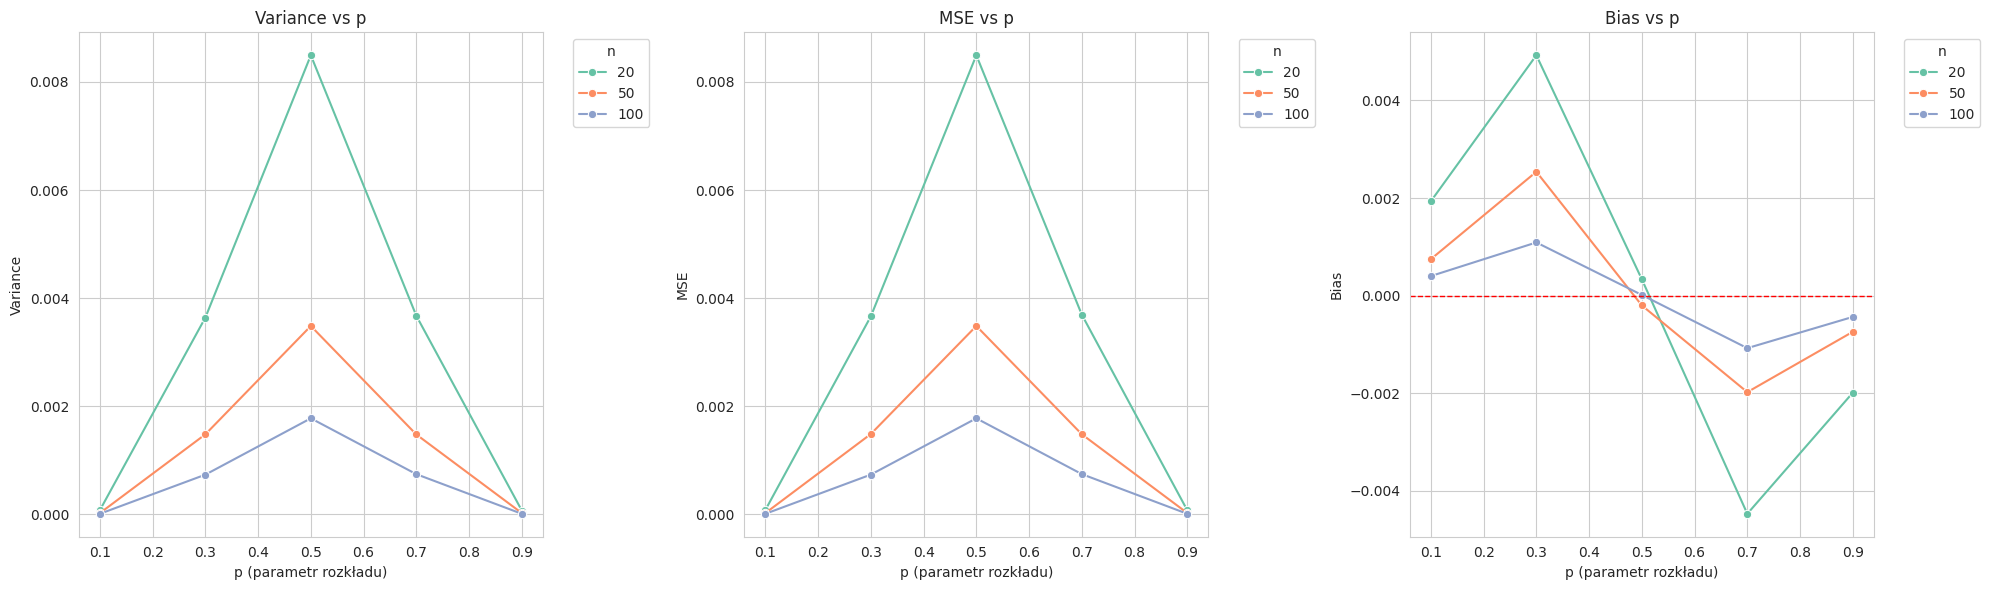

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Variance vs p dla każdego n
sns.lineplot(data=plot_df, x='p', y='var', hue='n', marker='o', ax=axes[0], palette='Set2')
axes[0].set_title('Variance vs p')
axes[0].set_xlabel('p (parametr rozkładu)')
axes[0].set_ylabel('Variance')
axes[0].legend(title='n', bbox_to_anchor=(1.05, 1), loc='upper left')

# MSE vs p dla każdego n
sns.lineplot(data=plot_df, x='p', y='mse', hue='n', marker='o', ax=axes[1], palette='Set2')
axes[1].set_title('MSE vs p')
axes[1].set_xlabel('p (parametr rozkładu)')
axes[1].set_ylabel('MSE')
axes[1].legend(title='n', bbox_to_anchor=(1.05, 1), loc='upper left')

# Bias vs p dla każdego n
sns.lineplot(data=plot_df, x='p', y='bias', hue='n', marker='o', ax=axes[2], palette='Set2')
axes[2].set_title('Bias vs p')
axes[2].set_xlabel('p (parametr rozkładu)')
axes[2].set_ylabel('Bias')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].legend(title='n', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

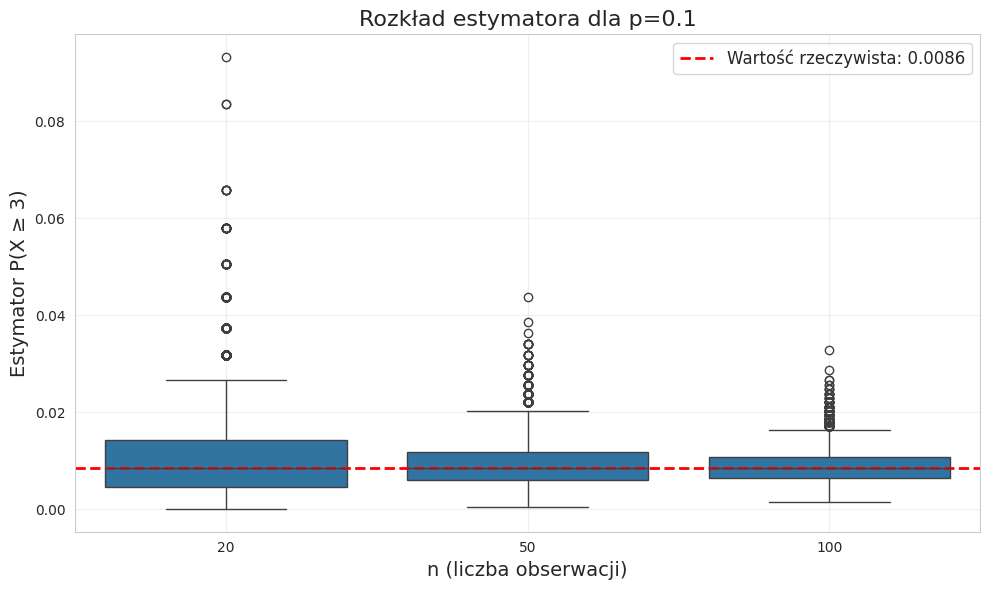

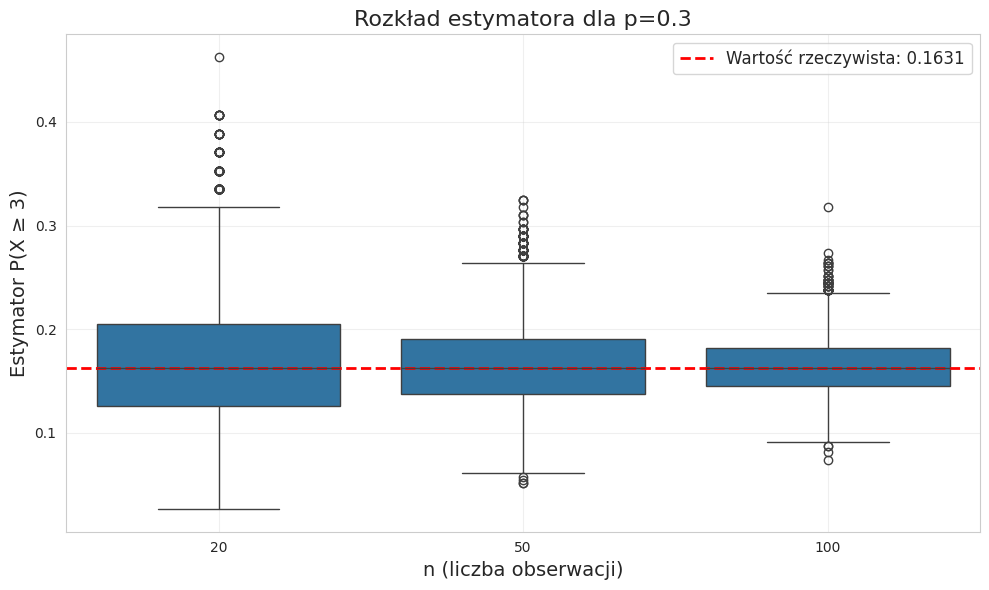

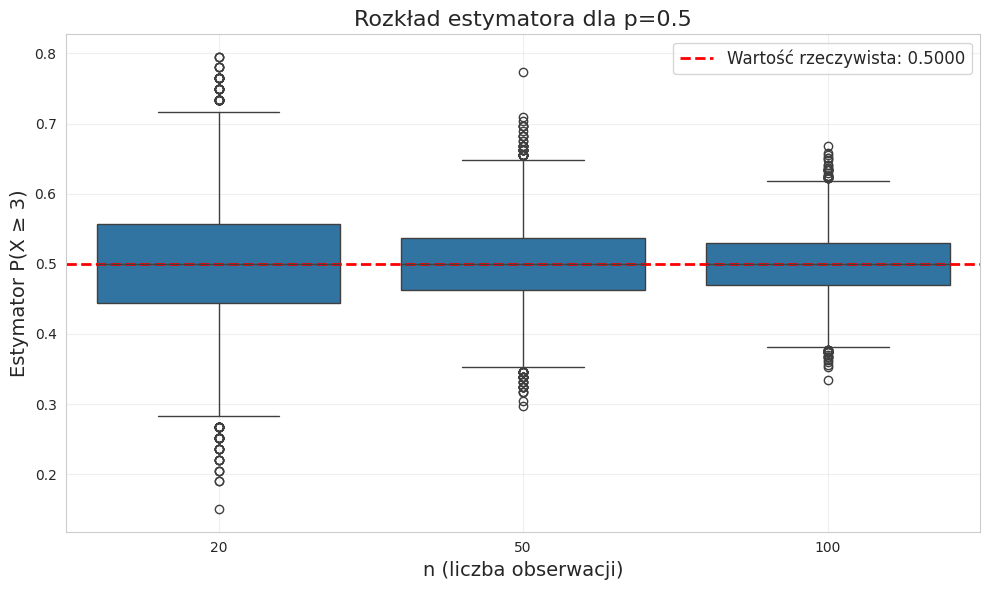

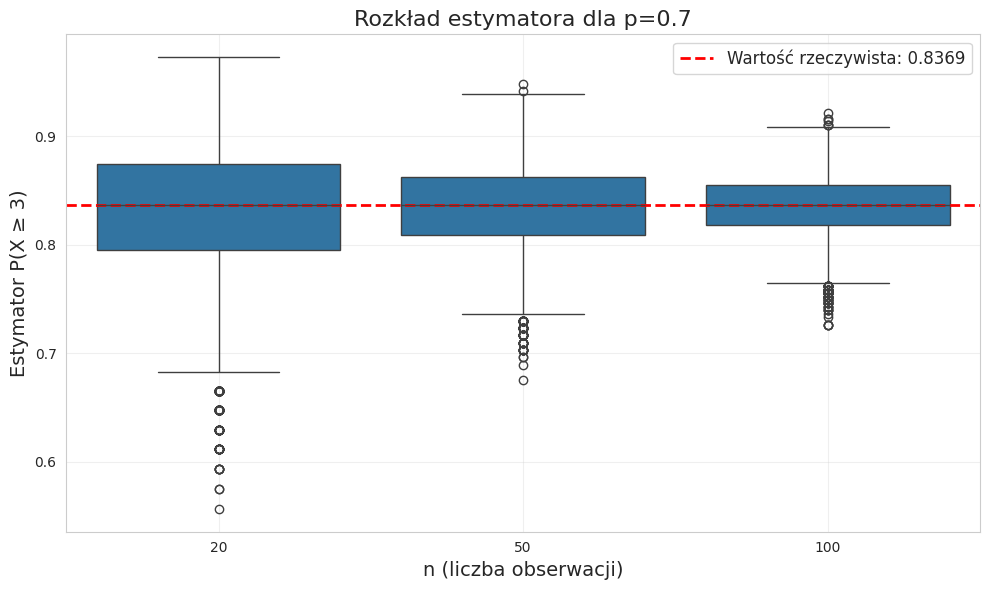

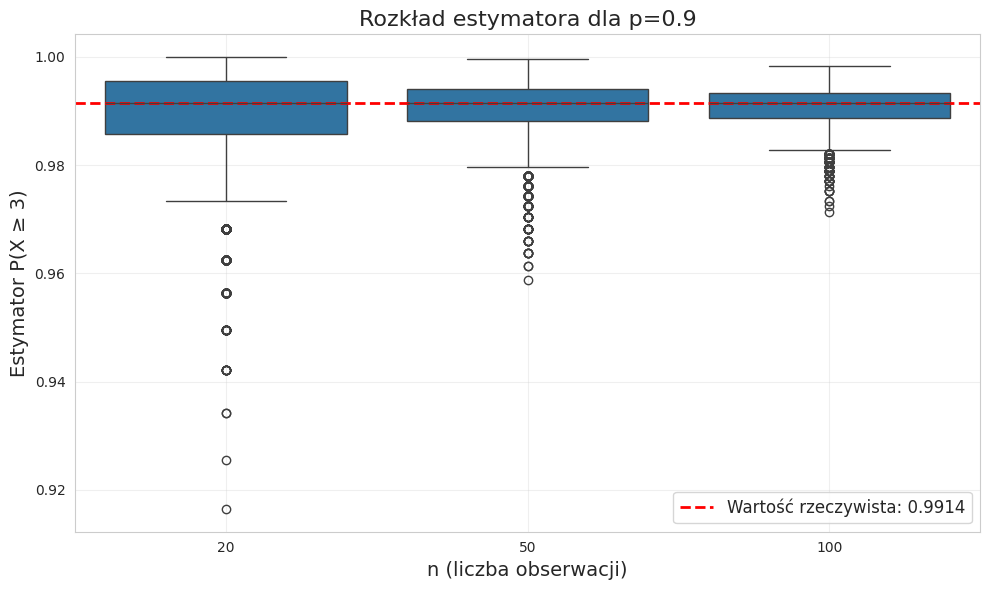

In [31]:
# Przygotowanie danych do boxplotów
boxplot_data = []
for (n, p), data in results.items():
    for value in data:
        boxplot_data.append({'n': n, 'p': round(p, 2), 'ppb_estimate': value})

boxplot_df = pd.DataFrame(boxplot_data)

# Tworzenie osobnych wykresów dla każdej wartości p
for p_val in ps:
    p_rounded = round(p_val, 2)
    subset = boxplot_df[boxplot_df['p'] == p_rounded]

    fig, ax = plt.subplots(figsize=(10, 6))

    sns.boxplot(data=subset, x='n', y='ppb_estimate', ax=ax)
    ax.set_title(f'Rozkład estymatora dla p={p_rounded}', fontsize=16)
    ax.set_xlabel('n (liczba obserwacji)', fontsize=14)
    ax.set_ylabel('Estymator P(X ≥ 3)', fontsize=14)

    # Dodaj teoretyczną wartość
    real_val = binom.pmf(3, 5, p_val) + binom.pmf(4, 5, p_val) + binom.pmf(5, 5, p_val)
    ax.axhline(real_val, color='red', linestyle='--', linewidth=2,
               label=f'Wartość rzeczywista: {real_val:.4f}')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Zadanie 2

In [34]:
def mle_beta(X):
    n = X.shape[1] if len(X.shape) > 1 else len(X)
    log_sum = np.sum(np.log(X), axis=1) if len(X.shape) > 1 else np.sum(np.log(X))
    return -n / log_sum

def fisher_information_estimate(theta_hat):
    return 1 / (theta_hat ** 2)

In [35]:
ns = [20, 50, 100]
thetas = [0.5, 1, 2, 5]
num_runs = 10000

summary_data = []
results_store = {}

for n in ns:
    for theta in thetas:
        # Generowanie macierzy danych (num_runs x n)
        X_matrix = beta.rvs(theta, 1, size=(num_runs, n))

        theta_mle_values = mle_beta(X_matrix)

        fisher_estimates = fisher_information_estimate(theta_mle_values)
        mean_fisher_est = np.mean(fisher_estimates)

        bias = np.mean(theta_mle_values) - theta
        variance = np.var(theta_mle_values)
        mse = np.mean((theta_mle_values - theta)**2)

        fisher_theoretical = 1 / (theta ** 2)

        summary_data.append({
            'n': n,
            'theta': theta,
            'Est. Fisher I(θ)': mean_fisher_est,
            'True Fisher I(θ)': fisher_theoretical,
            'Bias': bias,
            'Variance': variance,
            'MSE': mse
        })

        results_store[(n, theta)] = {
            'mle': theta_mle_values,
            'fisher_mean': mean_fisher_est
        }


In [36]:
df_summary = pd.DataFrame(summary_data)
print("--- Tabela Wyników Zbiorczych (Markdown) ---")
print(df_summary.to_markdown(index=False, floatfmt=".5f"))

--- Tabela Wyników Zbiorczych (Markdown) ---
|         n |   theta |   Est. Fisher I(θ) |   True Fisher I(θ) |    Bias |   Variance |     MSE |
|----------:|--------:|-------------------:|-------------------:|--------:|-----------:|--------:|
|  20.00000 | 0.50000 |            4.19303 |            4.00000 | 0.02602 |    0.01510 | 0.01578 |
|  20.00000 | 1.00000 |            1.04769 |            1.00000 | 0.05321 |    0.06070 | 0.06353 |
|  20.00000 | 2.00000 |            0.26414 |            0.25000 | 0.10127 |    0.24548 | 0.25574 |
|  20.00000 | 5.00000 |            0.04209 |            0.04000 | 0.26371 |    1.54551 | 1.61505 |
|  50.00000 | 0.50000 |            4.08814 |            4.00000 | 0.00946 |    0.00534 | 0.00543 |
|  50.00000 | 1.00000 |            1.01355 |            1.00000 | 0.02381 |    0.02203 | 0.02259 |
|  50.00000 | 2.00000 |            0.25518 |            0.25000 | 0.03942 |    0.08527 | 0.08683 |
|  50.00000 | 5.00000 |            0.04098 |            0.04000 

In [39]:
def plot_mle_analysis(n, theta, data_dict):
    theta_mle_values = data_dict['mle']
    fisher_info_est = data_dict['fisher_mean']

    fig = plt.figure(figsize=(18, 5))

    # Parametry rozkładu asymptotycznego: N(theta, 1 / (n * I(theta)))
    asymptotic_var = 1 / (n * fisher_info_est)
    asymptotic_std = np.sqrt(asymptotic_var)

    # 1. Boxplot
    ax1 = plt.subplot(1, 3, 1)
    sns.boxplot(y=theta_mle_values, ax=ax1, color='lightblue', showfliers=False)
    ax1.axhline(theta, color='red', linestyle='--', linewidth=2, label=f'True θ = {theta}')
    ax1.set_title(f'Boxplot MLE\nn={n}, θ={theta}', fontsize=14)
    ax1.set_ylabel(r'$\hat{\theta}_{MLE}$', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Histogram z gęstością asymptotyczną
    ax2 = plt.subplot(1, 3, 2)

    q1, q99 = np.percentile(theta_mle_values, [0.5, 99.5])
    filtered_data = theta_mle_values[(theta_mle_values >= q1) & (theta_mle_values <= q99)]

    ax2.hist(filtered_data, bins=40, density=True, alpha=0.6, color='skyblue', edgecolor='gray', label='Histogram')

    x_range = np.linspace(filtered_data.min(), filtered_data.max(), 1000)
    pdf_asymp = norm.pdf(x_range, loc=theta, scale=asymptotic_std)
    ax2.plot(x_range, pdf_asymp, 'r-', linewidth=2, label='Asymptotyczna N(θ, $\sigma^2$)')

    ax2.set_title(f'Histogram + Rozkład Asymptotyczny\nn={n}, θ={theta}', fontsize=14)
    ax2.legend()

    # 3. QQ-Plot
    ax3 = plt.subplot(1, 3, 3)
    standardized_mle = (theta_mle_values - theta) / asymptotic_std
    probplot(standardized_mle, dist="norm", plot=ax3)
    ax3.set_title(f'Q-Q Plot (vs Normalny)\nn={n}, θ={theta}', fontsize=14)
    ax3.get_lines()[0].set_markerfacecolor('C0')
    ax3.get_lines()[0].set_markersize(4.0)
    ax3.get_lines()[1].set_linewidth(2.0)
    ax3.get_lines()[1].set_color('red')

    plt.tight_layout()
    plt.show()

<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7200/3202535675.py:30: SyntaxWarning: invalid escape sequence '\s'
  ax2.plot(x_range, pdf_asymp, 'r-', linewidth=2, label='Asymptotyczna N(θ, $\sigma^2$)')


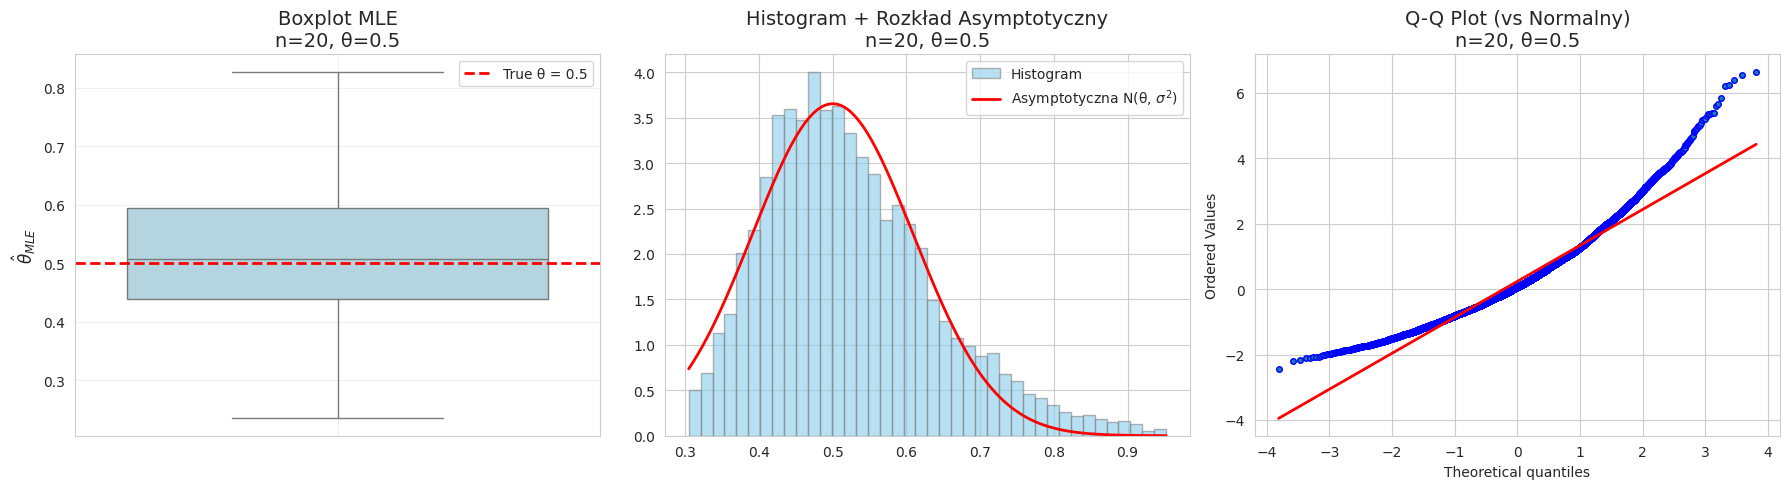

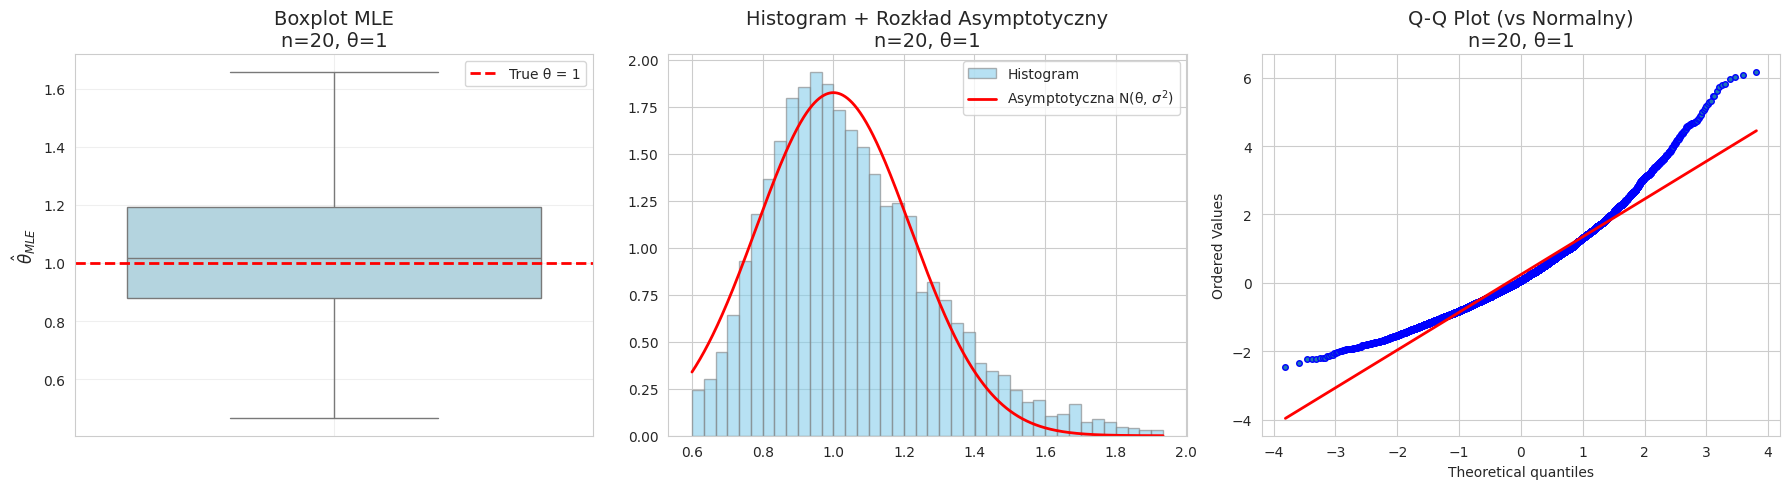

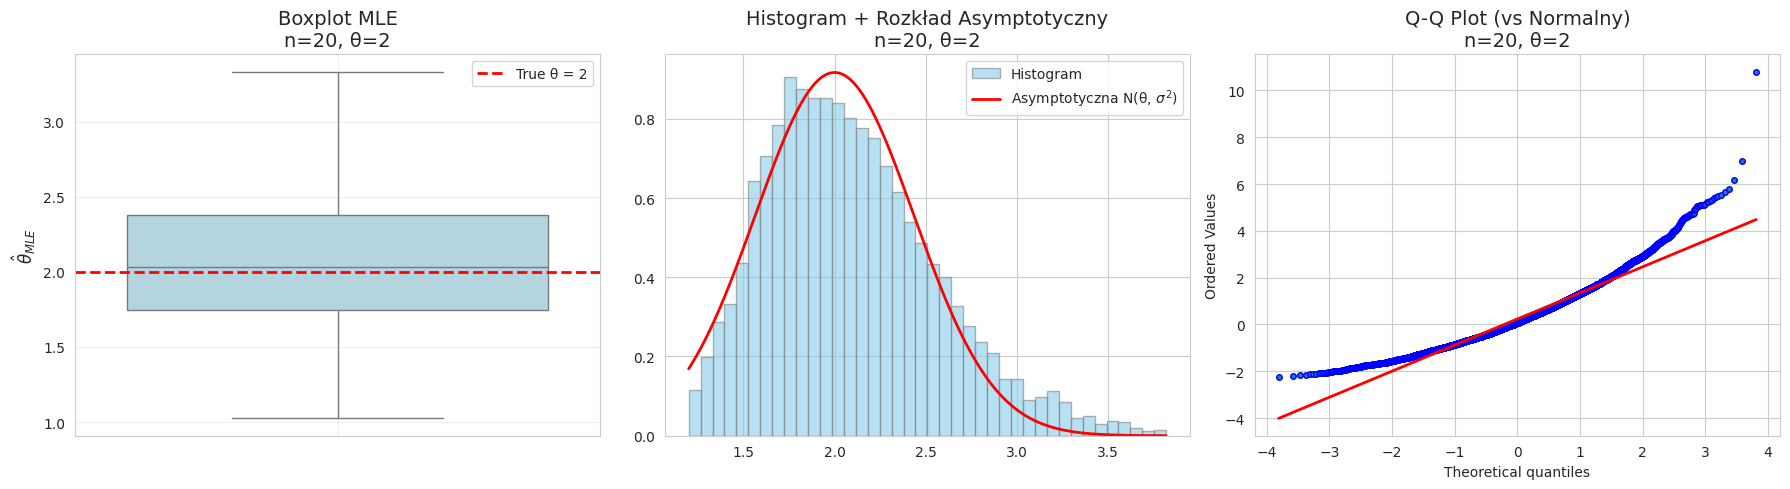

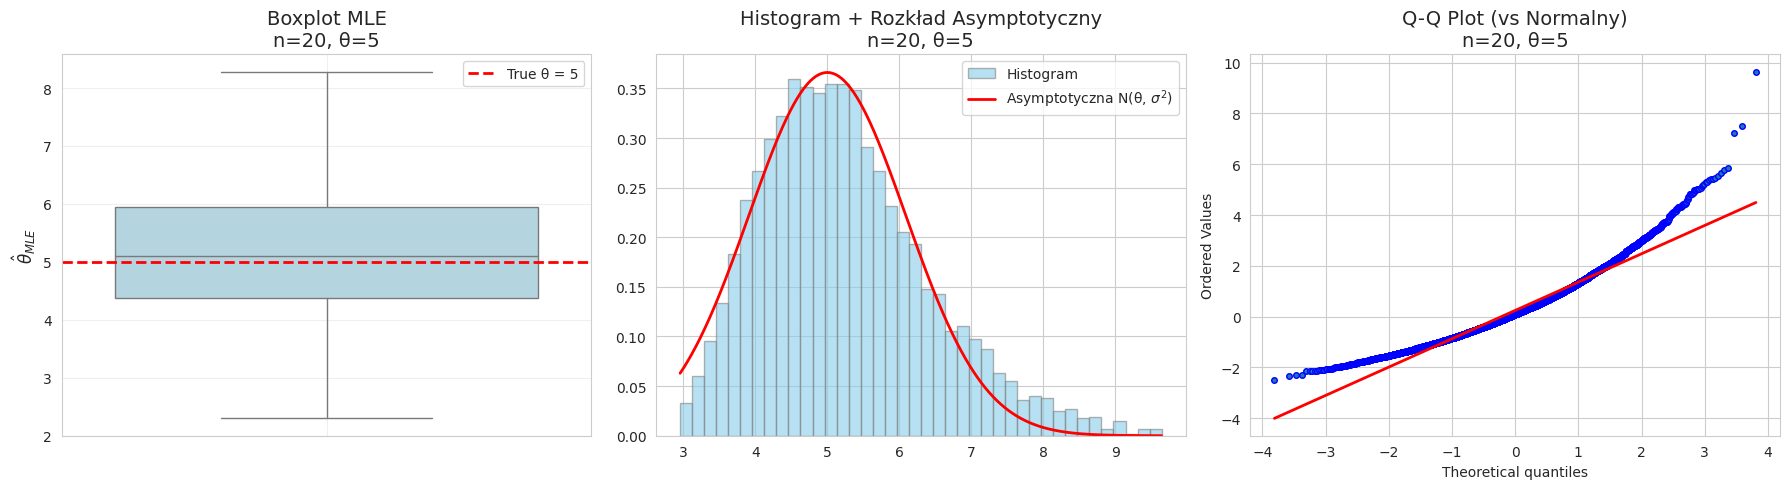

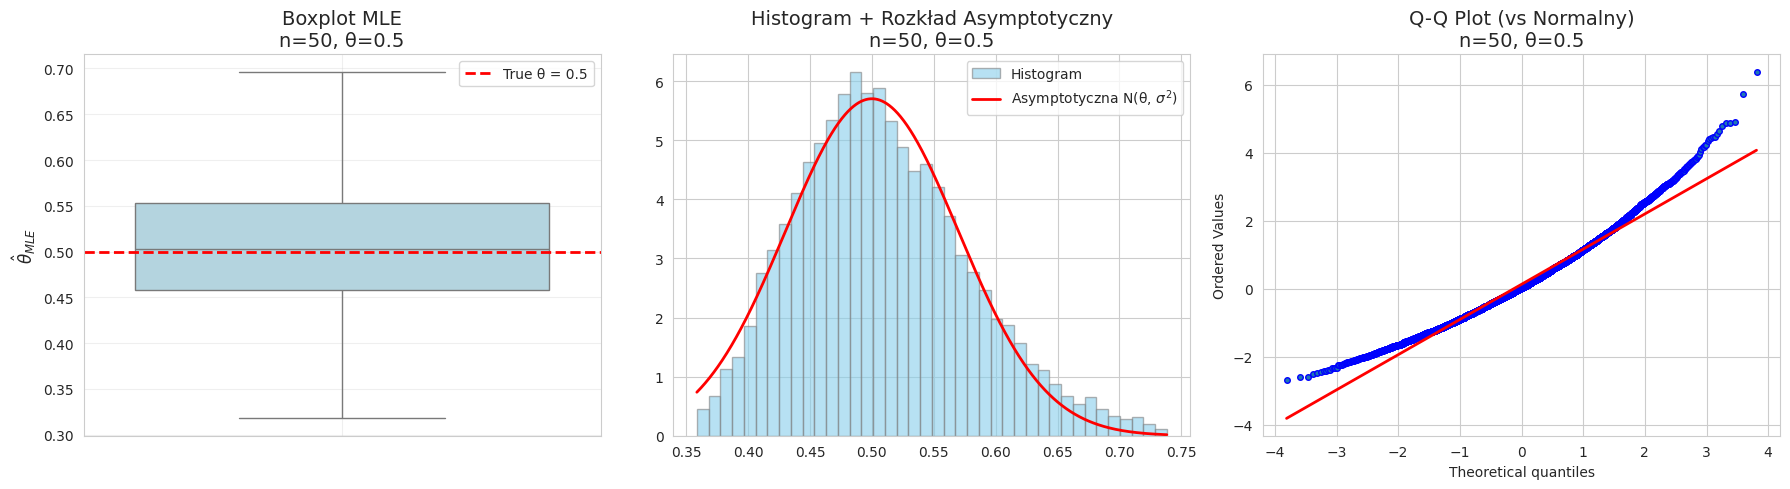

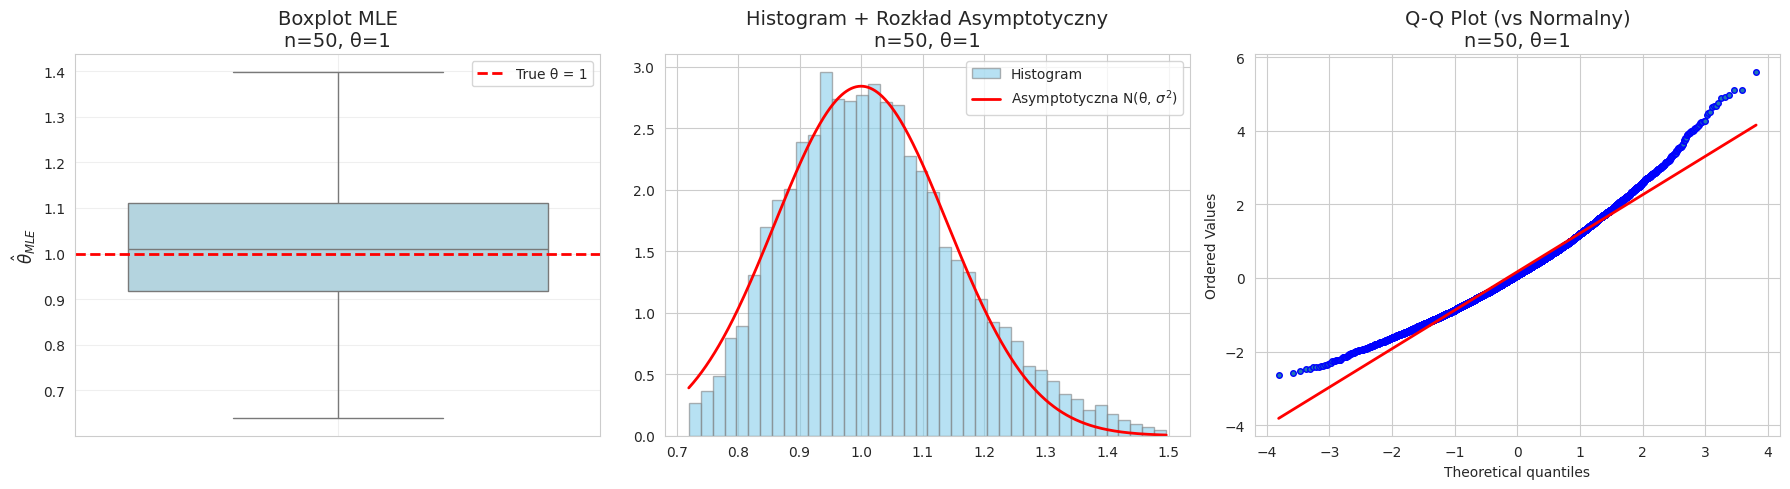

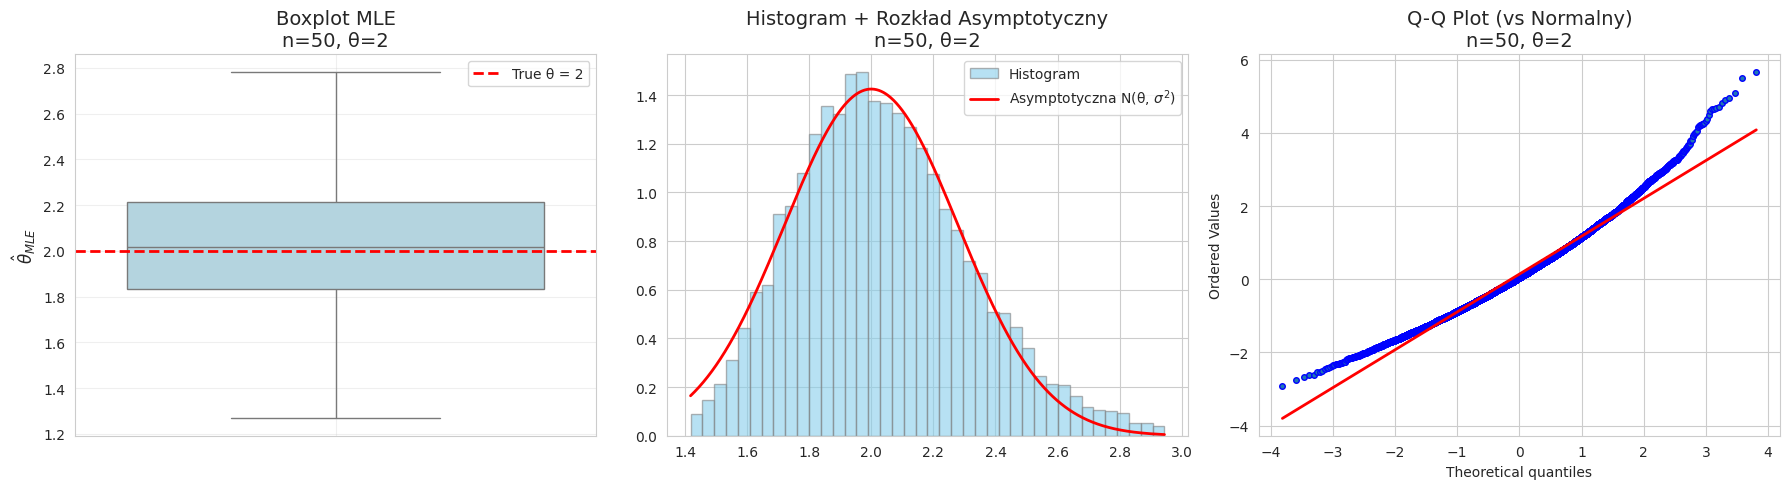

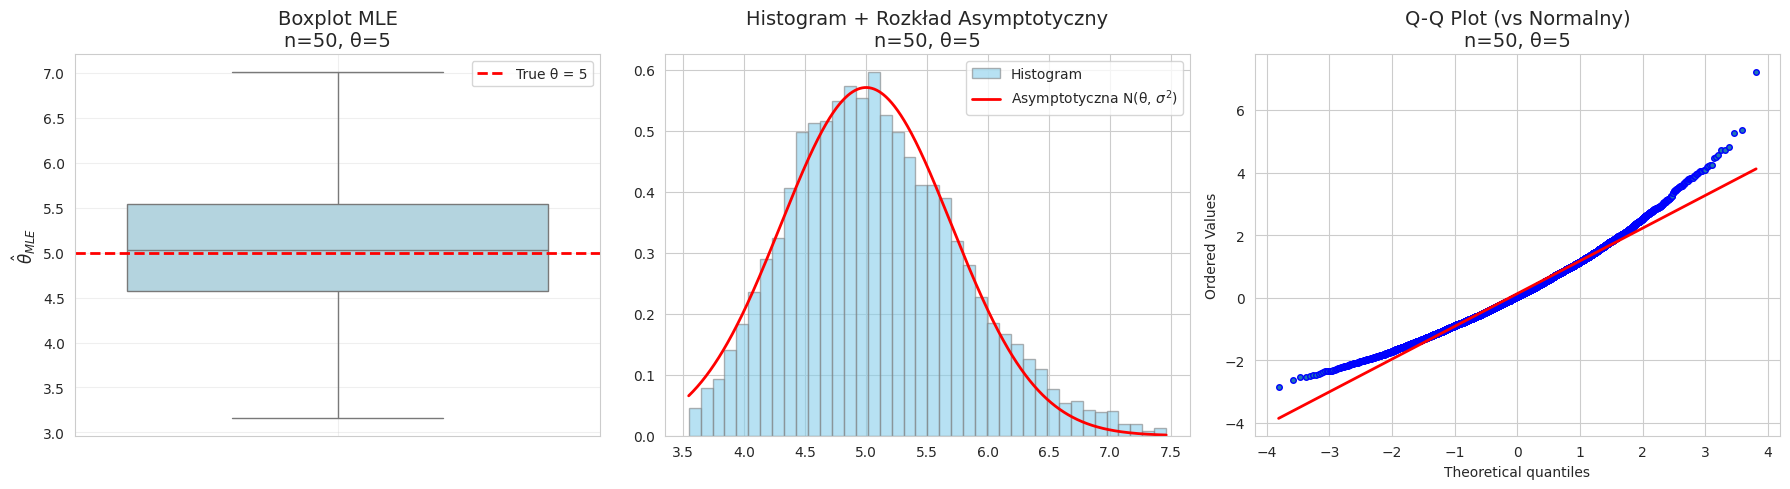

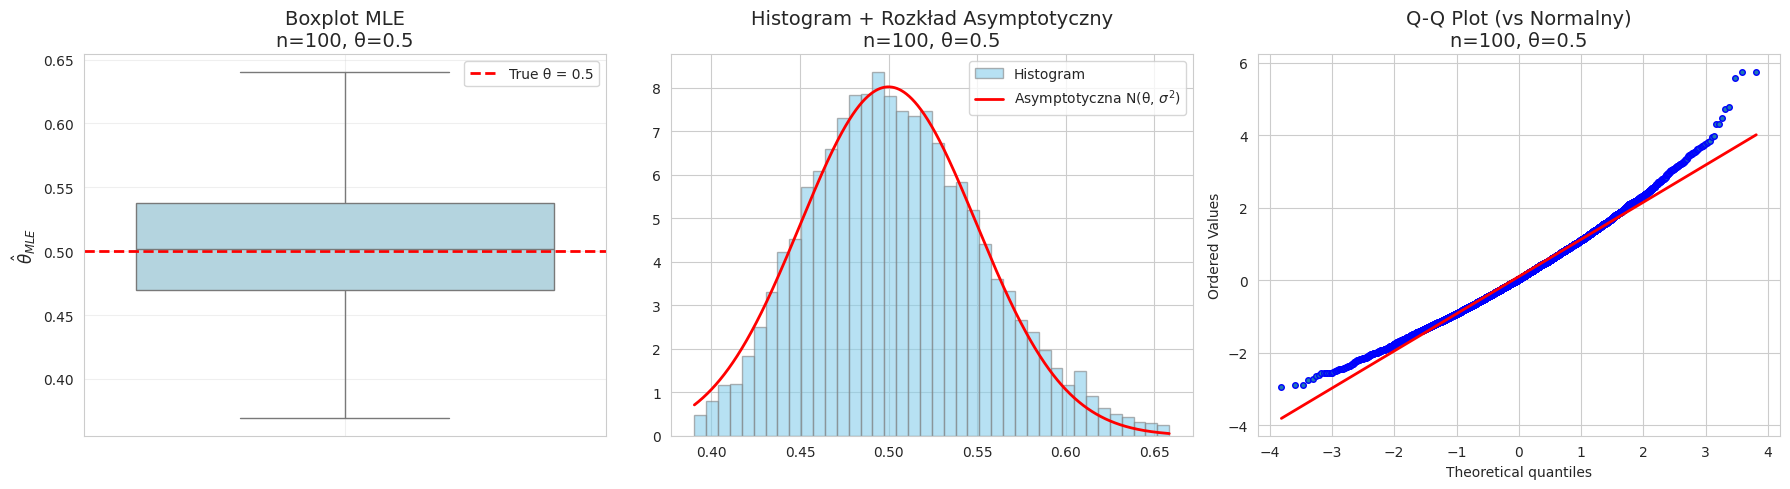

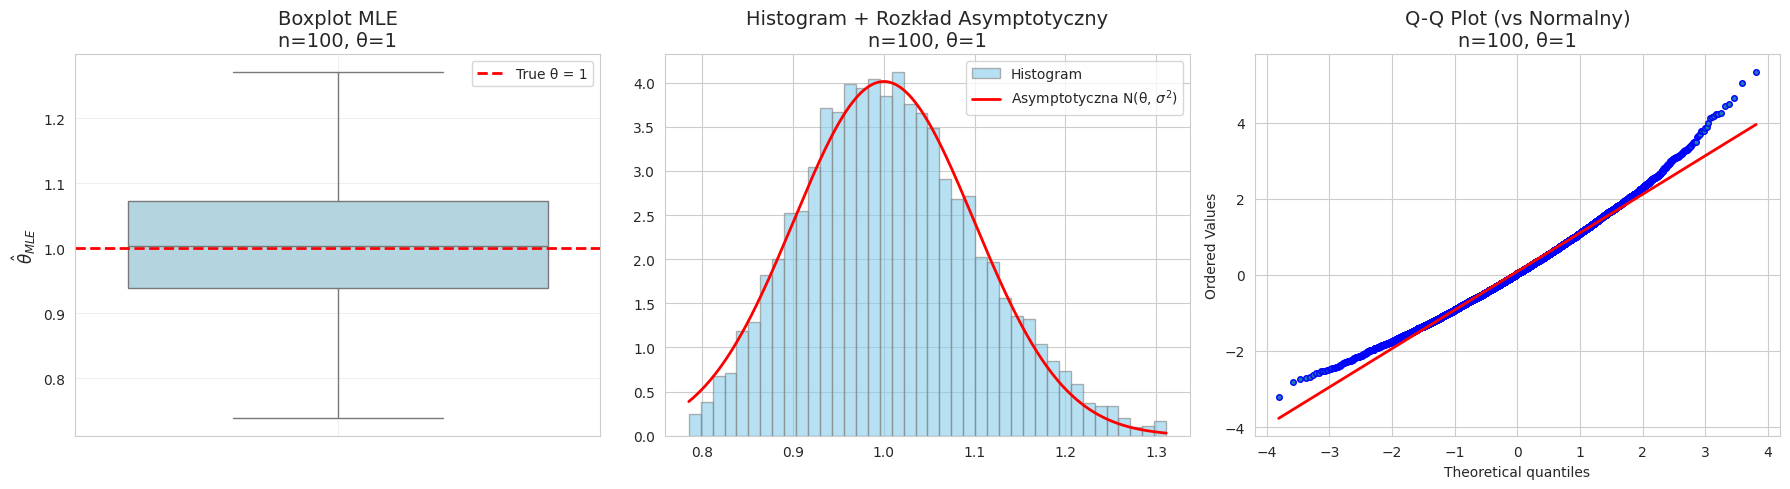

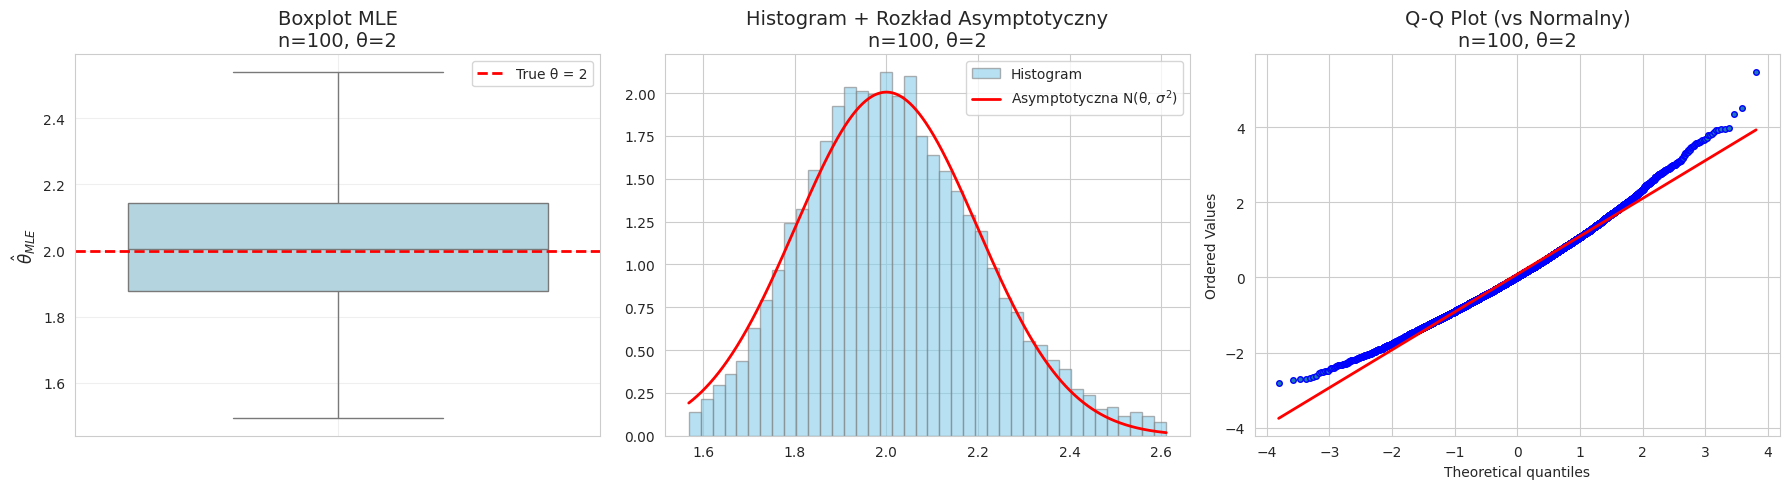

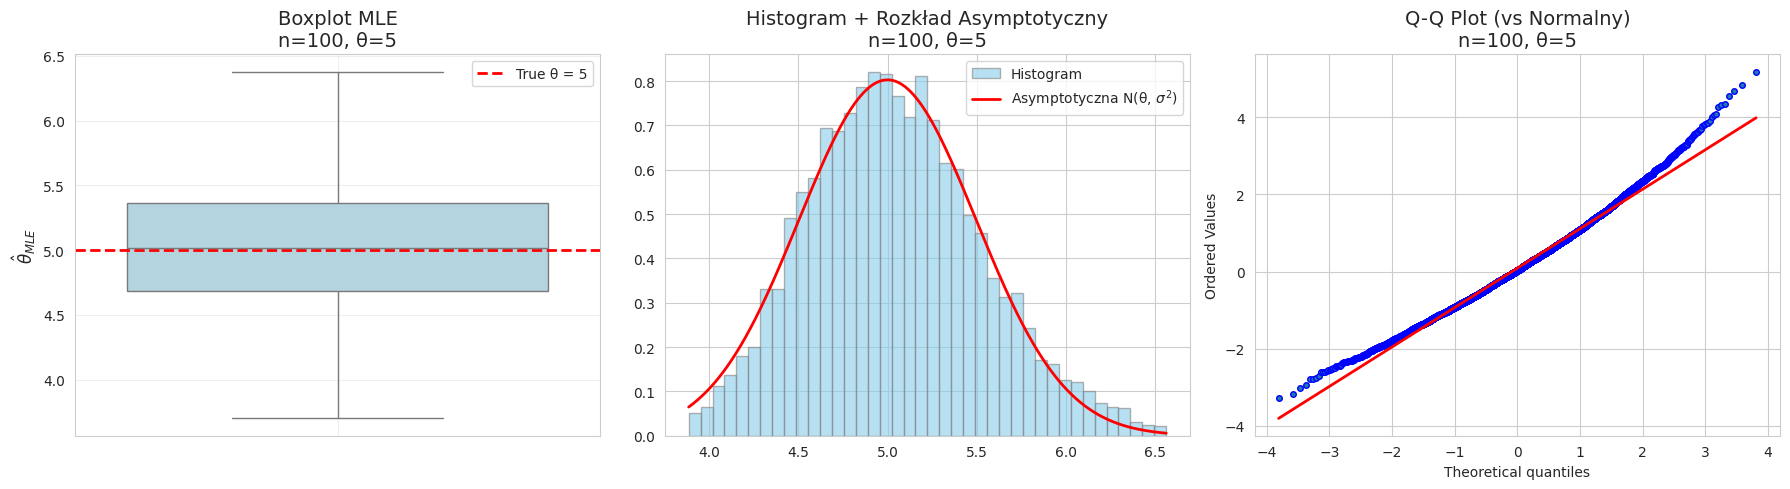

In [41]:
for n in ns:
    for theta in thetas:
        plot_mle_analysis(n, theta, results_store[(n, theta)])

## Zadanie 3

Dla rozkładu Logistic(θ, σ) szukamy MLE dla parametru θ (lokalizacja).
Funkcja log-likelihood: log L(θ, σ | X) = -n·log(σ) - Σlog(1 + exp((Xi - θ)/σ)) - Σ((Xi - θ)/σ)

Zbadamy wpływ punktu początkowego na zbieżność algorytmu optymalizacji.

In [10]:
def neg_log_likelihood(theta_hat, data, sigma_known):
    """
    Ujemna logarytmiczna funkcja wiarogodności dla rozkładu logistycznego.
    Optymalizujemy tylko theta, zakładając sigma jako znaną (lub ustaloną w hipotezie).
    """
    # pdf = (1/sigma) * exp(-(x-theta)/sigma) / (1 + exp(-(x-theta)/sigma))^2
    # log_pdf = -ln(sigma) - (x-theta)/sigma - 2*ln(1 + exp(-(x-theta)/sigma))
    # NLL = - sum(log_pdf)

    z = (data - theta_hat) / sigma_known
    # Używamy funkcji logistycznej z scipy dla stabilności numerycznej lub wzoru ręcznego
    # Wzór uproszczony dla sumy:
    n = len(data)
    # logL = -n*np.log(sigma_known) - np.sum(z) - 2*np.sum(np.log1p(np.exp(-z)))
    # Minimalizujemy ujemną log-wiarogodność, stałe (sigma) można pominąć przy pochodnej,
    # ale zostawiamy dla poprawności wartości funkcji.

    # Wersja numerycznie stabilna (korzystając z log-sum-exp trick wbudowanego w biblioteki lub prościej):
    # Dla optymalizacji wystarczy zminimalizować: sum( z + 2*log(1 + exp(-z)) )
    term2 = 2 * np.log1p(np.exp(-z))
    return np.sum(z + term2)

def solve_mle(data, sigma_known, start_point=0):
    """Rozwiązuje problem minimalizacji NLL, aby znaleźć theta_MLE."""
    res = minimize(
        neg_log_likelihood,
        x0=[start_point],
        args=(data, sigma_known),
        method='BFGS' # Metoda quasi-Newtona (efektywna dla funkcji gładkich)
    )
    return res.x[0], res.nit  # Zwraca estymator i liczbę iteracji


In [22]:
def run_simulation():
    results_list = []
    for case in CASES:
        theta_true = case['theta']
        sigma_true = case['sigma']
        case_label = case['label']

        for n in N_VALUES:
            # Generujemy macierz danych: (REPETITIONS x n)
            data_matrix = logistic.rvs(loc=theta_true, scale=sigma_true, size=(REPETITIONS, n))

            estimates = []

            # Obliczamy MLE dla każdej próby
            for i in range(REPETITIONS):
                row = data_matrix[i, :]
                # Startujemy od mediany (przyspieszenie zbieżności)
                est, _ = solve_mle(row, sigma_true, start_point=np.median(row))
                estimates.append(est)

            # Zapisujemy TYLKO surowe wyniki.
            # Metryki (MSE, Bias) policzymy później zbiorczo z Pandas.
            for est in estimates:
                results_list.append({
                    'Case': case_label,
                    'n': n,
                    'theta_true': theta_true,
                    'sigma_true': sigma_true,
                    'Estimated_Theta': est
                })

    return pd.DataFrame(results_list)

|   Start X0 |   Steps |   Result MLE |
|-----------:|--------:|-------------:|
|   -10.0000 |  4.0000 |       3.6761 |
|     0.0000 |  5.0000 |       3.6761 |
|     4.0000 |  3.0000 |       3.6761 |
|    10.0000 |  5.0000 |       3.6761 |
|    20.0000 |  6.0000 |       3.6761 |




/tmp/ipykernel_7200/4085755458.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df_results.groupby(['Case', 'n']).apply(


--- Wyniki zbiorcze (Bias, Variance, MSE) ---
| Case         |   n |     Bias |   Variance |     MSE |
|:-------------|----:|---------:|-----------:|--------:|
| (a) θ=0, σ=1 |  20 |  0.00249 |    0.15012 | 0.15012 |
| (a) θ=0, σ=1 |  50 |  0.00096 |    0.06071 | 0.06071 |
| (a) θ=0, σ=1 | 100 | -0.00156 |    0.03026 | 0.03026 |
| (b) θ=0, σ=2 |  20 | -0.00349 |    0.62884 | 0.62885 |
| (b) θ=0, σ=2 |  50 | -0.00022 |    0.24076 | 0.24076 |
| (b) θ=0, σ=2 | 100 |  0.00277 |    0.12124 | 0.12125 |
| (c) θ=4, σ=1 |  20 | -0.00371 |    0.15088 | 0.15089 |
| (c) θ=4, σ=1 |  50 |  0.00176 |    0.06074 | 0.06075 |
| (c) θ=4, σ=1 | 100 | -0.00103 |    0.02939 | 0.02939 |
| (d) θ=4, σ=2 |  20 |  0.00582 |    0.58553 | 0.58556 |
| (d) θ=4, σ=2 |  50 | -0.00077 |    0.24183 | 0.24183 |
| (d) θ=4, σ=2 | 100 | -0.00286 |    0.11940 | 0.11940 |


<Figure size 1200x800 with 0 Axes>

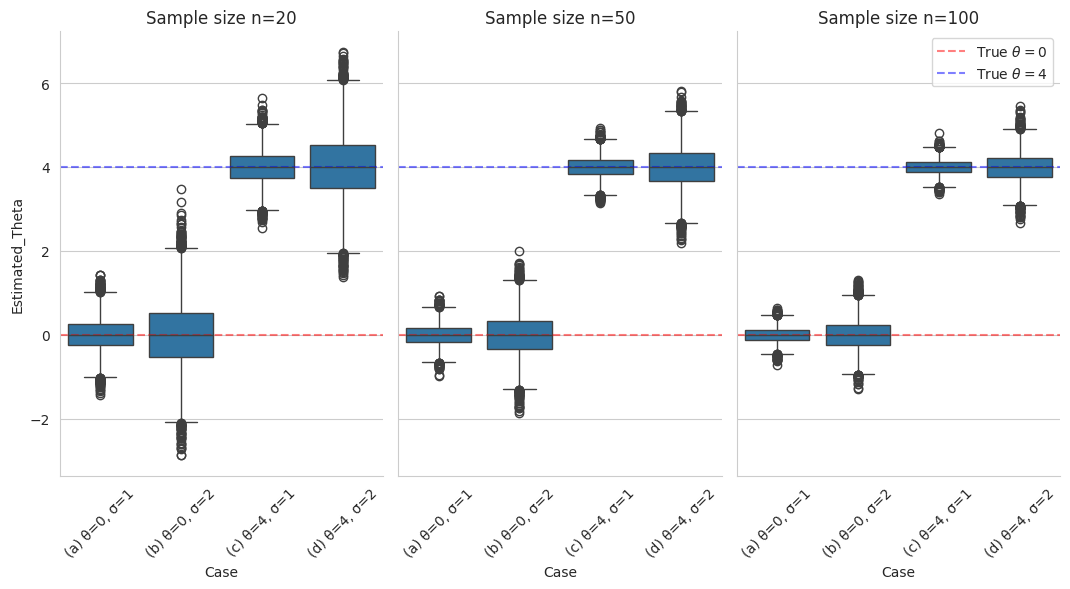

In [26]:
N_VALUES = [20, 50, 100]          # Rozmiary prób
REPETITIONS = 10000               # Liczba powtórzeń
CASES = [
    {'theta': 0, 'sigma': 1, 'label': '(a) θ=0, σ=1'}, #
    {'theta': 0, 'sigma': 2, 'label': '(b) θ=0, σ=2'}, #
    {'theta': 4, 'sigma': 1, 'label': '(c) θ=4, σ=1'}, #
    {'theta': 4, 'sigma': 2, 'label': '(d) θ=4, σ=2'}  #
]

def analyze_starting_points():
    test_n = 50
    test_case = CASES[2] # theta=4, sigma=1

    # Generujemy jedną próbkę
    np.random.seed(42)
    data = logistic.rvs(loc=test_case['theta'], scale=test_case['sigma'], size=test_n)

    start_points = [-10, 0, 4, 10, 20] # Różne punkty startowe

    results = []
    for x0 in start_points:
        est, steps = solve_mle(data, test_case['sigma'], start_point=x0)
        results.append({'Start X0': x0, 'Steps': steps, 'Result MLE': est})

    df_start = pd.DataFrame(results)
    print(df_start.to_markdown(index=False, floatfmt=".4f"))
    print("\n")

# 1. Analiza punktów startowych
analyze_starting_points()

# 2. Główna symulacja
df_results = run_simulation()

# 3. Obliczanie tabeli podsumowującej (Bias, MSE, Var)
summary = df_results.groupby(['Case', 'n']).apply(
    lambda x: pd.Series({
        'Bias': np.mean(x['Estimated_Theta']) - x['theta_true'].iloc[0],
        'Variance': np.var(x['Estimated_Theta']),
        'MSE': np.mean((x['Estimated_Theta'] - x['theta_true'].iloc[0])**2)
    })
).reset_index()

print("--- Wyniki zbiorcze (Bias, Variance, MSE) ---")
print(summary.to_markdown(index=False, floatfmt=".5f"))

# 4. Wykresy
# Wykresy pudełkowe porównujące estymatory dla różnych n i przypadków
plt.figure(figsize=(12, 8))
g = sns.FacetGrid(df_results, col="n", sharey=True, height=6, aspect=0.6)
g.map(sns.boxplot, "Case", "Estimated_Theta", order=[c['label'] for c in CASES])

# Dodanie linii prawdziwej wartości theta
for ax, n_val in zip(g.axes.flat, N_VALUES):
    # Rysujemy linie referencyjne dla theta=0 i theta=4
    ax.axhline(0, color='r', linestyle='--', alpha=0.5, label='True $\\theta=0$')
    ax.axhline(4, color='b', linestyle='--', alpha=0.5, label='True $\\theta=4$')
    ax.set_title(f"Sample size n={n_val}")
    ax.tick_params(axis='x', rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

## Zadanie 4

### Podpunkt a

In [47]:
def solve_beta_estimators(data):
    # MLE: theta = -n / sum(ln(x))
    n = data.shape[1]
    log_sum = np.sum(np.log(data), axis=1)
    theta_mle = -n / log_sum

    # MOM: theta = mean / (1 - mean)
    sample_mean = np.mean(data, axis=1)
    theta_mom = sample_mean / (1 - sample_mean)

    return theta_mle, theta_mom

def run_beta_simulation():
    ns = [20, 50, 100]
    thetas = [0.5, 1, 2, 5]
    n_runs = 10000

    results = []
    summary_list = []

    for n in ns:
        for theta in thetas:
            data = beta.rvs(theta, 1, size=(n_runs, n))
            mle_vals, mom_vals = solve_beta_estimators(data)

            # Zbieranie danych
            for v in mle_vals:
                results.append({'n': n, 'theta': theta, 'Method': 'MLE', 'Value': v})
            for v in mom_vals:
                results.append({'n': n, 'theta': theta, 'Method': 'MOM', 'Value': v})

            # Metryki
            for method_name, vals in [('MLE', mle_vals), ('MOM', mom_vals)]:
                summary_list.append({
                    'n': n,
                    'theta': theta,
                    'Method': method_name,
                    'Bias': np.mean(vals) - theta,
                    'Variance': np.var(vals),
                    'MSE': np.mean((vals - theta)**2)
                })

    return pd.DataFrame(results), pd.DataFrame(summary_list)

df_raw_beta, df_summary_beta = run_beta_simulation()

print(df_summary_beta.sort_values(by=['theta', 'n', 'Method']).to_markdown(index=False, floatfmt=".4f"))

Symulacja Zadanie 4a (Beta) w toku...
--- Wyniki Zadanie 4a: Beta(theta, 1) ---
|   n |   theta | Method   |   Bias |   Variance |    MSE |
|----:|--------:|:---------|-------:|-----------:|-------:|
|  20 |  0.5000 | MLE      | 0.0246 |     0.0147 | 0.0153 |
|  20 |  0.5000 | MOM      | 0.0147 |     0.0244 | 0.0246 |
|  50 |  0.5000 | MLE      | 0.0104 |     0.0054 | 0.0055 |
|  50 |  0.5000 | MOM      | 0.0056 |     0.0092 | 0.0092 |
| 100 |  0.5000 | MLE      | 0.0052 |     0.0026 | 0.0026 |
| 100 |  0.5000 | MOM      | 0.0035 |     0.0046 | 0.0046 |
|  20 |  1.0000 | MLE      | 0.0548 |     0.0618 | 0.0648 |
|  20 |  1.0000 | MOM      | 0.0370 |     0.0774 | 0.0788 |
|  50 |  1.0000 | MLE      | 0.0209 |     0.0215 | 0.0219 |
|  50 |  1.0000 | MOM      | 0.0134 |     0.0281 | 0.0283 |
| 100 |  1.0000 | MLE      | 0.0098 |     0.0104 | 0.0105 |
| 100 |  1.0000 | MOM      | 0.0072 |     0.0137 | 0.0137 |
|  20 |  2.0000 | MLE      | 0.1046 |     0.2479 | 0.2588 |
|  20 |  2.0000 | MO

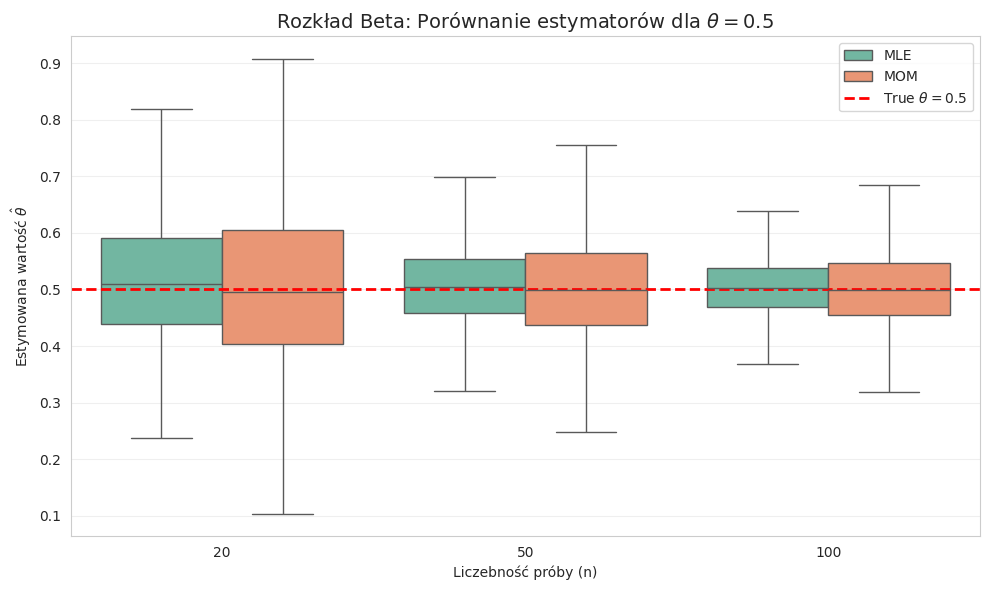

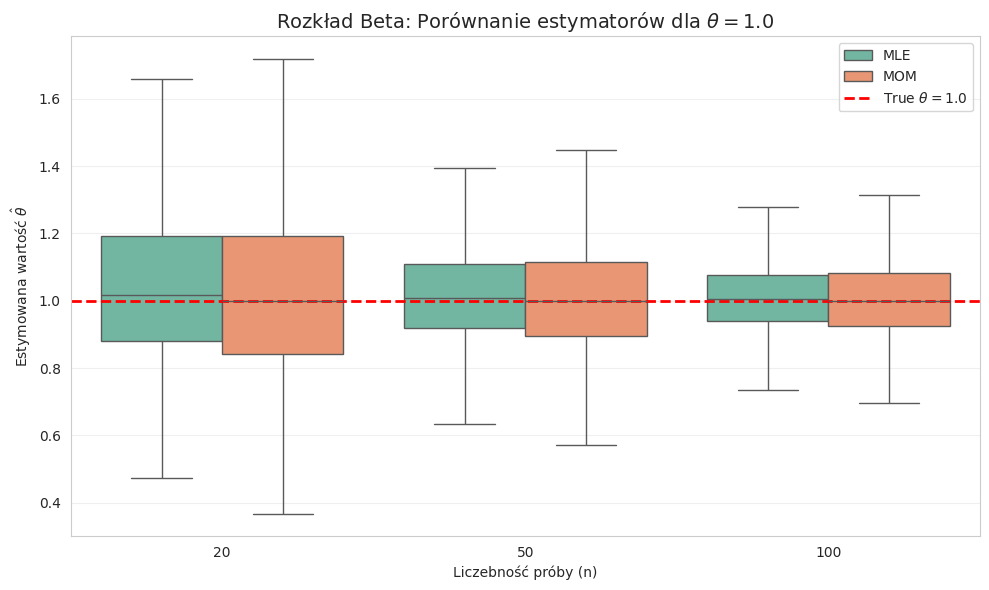

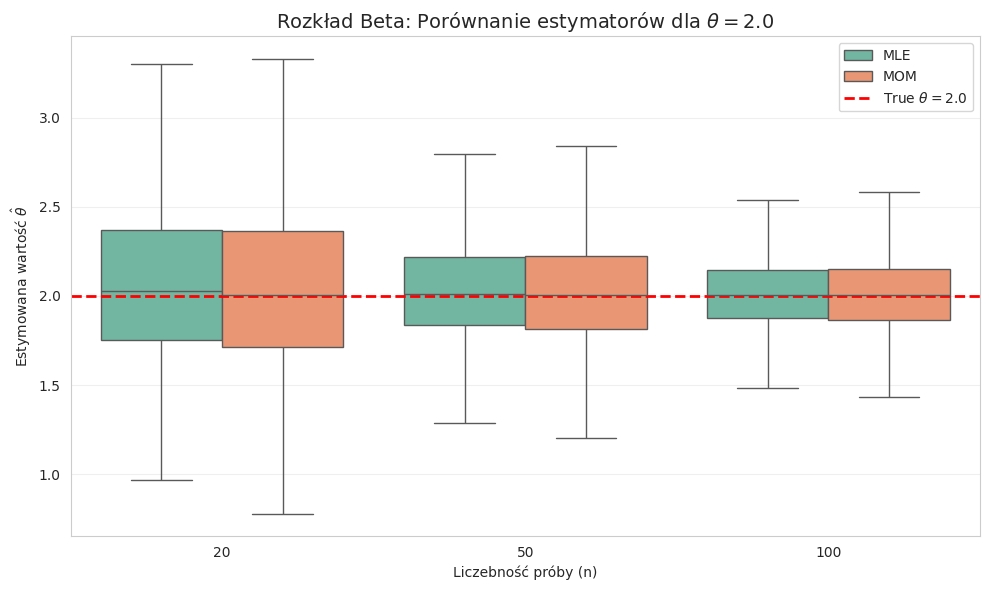

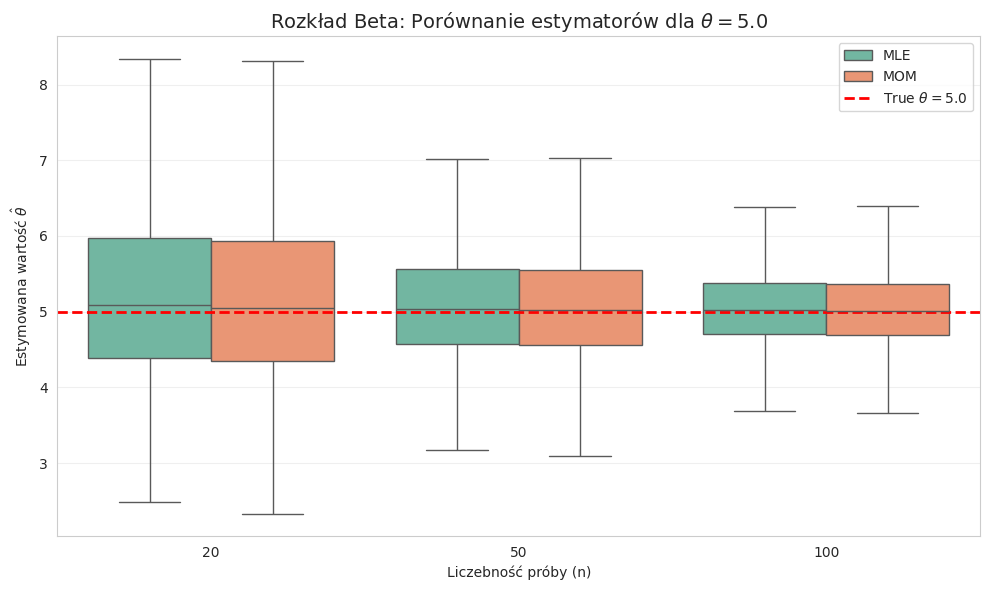

In [48]:
# Generowanie osobnego wykresu dla każdej wartości theta
unique_thetas = sorted(df_raw_beta['theta'].unique())

for theta in unique_thetas:
    plt.figure(figsize=(10, 6))

    # Filtrujemy dane tylko dla konkretnego theta
    subset = df_raw_beta[df_raw_beta['theta'] == theta]

    # Rysujemy boxplot: X to wielkość próby (n), Y to wartość estymatora
    sns.boxplot(x="n", y="Value", hue="Method", data=subset,
                palette="Set2", showfliers=False)

    # Linia referencyjna (prawdziwa wartość)
    plt.axhline(theta, color='red', linestyle='--', linewidth=2, label=f'True $\\theta={theta}$')

    plt.title(f'Rozkład Beta: Porównanie estymatorów dla $\\theta = {theta}$', fontsize=14)
    plt.ylabel('Estymowana wartość $\\hat{\\theta}$')
    plt.xlabel('Liczebność próby (n)')
    plt.legend(loc='upper right')
    plt.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

### Podpunkt b

In [45]:
def solve_lognorm_estimators(data):
    # MLE: średnia z logarytmów
    theta_mle = np.mean(np.log(data), axis=1)

    # MOM: mu = ln(mean) - 0.5 * ln(1 + var/mean^2)
    m1 = np.mean(data, axis=1)
    m2 = np.var(data, axis=1)
    theta_mom = np.log(m1) - 0.5 * np.log(1 + m2 / (m1**2))

    return theta_mle, theta_mom

def run_lognorm_simulation():
    ns = [20, 50, 100]
    # (theta, sigma)
    cases = [(0, 1), (4, 1), (0, 2), (4, 2)]
    n_runs = 10000

    results = []
    summary_list = []

    for n in ns:
        for (theta, sigma) in cases:
            case_label = f"θ={theta}, σ={sigma}"
            data = lognorm.rvs(s=sigma, scale=np.exp(theta), size=(n_runs, n))

            mle_vals, mom_vals = solve_lognorm_estimators(data)

            for v in mle_vals:
                results.append({'n': n, 'Case': case_label, 'theta': theta, 'Method': 'MLE', 'Value': v})
            for v in mom_vals:
                results.append({'n': n, 'Case': case_label, 'theta': theta, 'Method': 'MOM', 'Value': v})

            for method_name, vals in [('MLE', mle_vals), ('MOM', mom_vals)]:
                summary_list.append({
                    'n': n,
                    'Case': case_label,
                    'theta': theta,
                    'Method': method_name,
                    'Bias': np.mean(vals) - theta,
                    'Variance': np.var(vals),
                    'MSE': np.mean((vals - theta)**2)
                })

    return pd.DataFrame(results), pd.DataFrame(summary_list)

df_raw_log, df_summary_log = run_lognorm_simulation()

print(df_summary_log.drop(columns=['theta']).sort_values(by=['Case', 'n', 'Method']).to_markdown(index=False, floatfmt=".4f"))

|   n | Case     | Method   |    Bias |   Variance |    MSE |
|----:|:---------|:---------|--------:|-----------:|-------:|
|  20 | θ=0, σ=1 | MLE      |  0.0028 |     0.0512 | 0.0512 |
|  20 | θ=0, σ=1 | MOM      |  0.0973 |     0.0579 | 0.0674 |
|  50 | θ=0, σ=1 | MLE      | -0.0021 |     0.0199 | 0.0199 |
|  50 | θ=0, σ=1 | MOM      |  0.0592 |     0.0255 | 0.0290 |
| 100 | θ=0, σ=1 | MLE      | -0.0011 |     0.0101 | 0.0101 |
| 100 | θ=0, σ=1 | MOM      |  0.0400 |     0.0163 | 0.0179 |
|  20 | θ=0, σ=2 | MLE      |  0.0063 |     0.1953 | 0.1953 |
|  20 | θ=0, σ=2 | MOM      |  0.8560 |     0.3636 | 1.0963 |
|  50 | θ=0, σ=2 | MLE      | -0.0009 |     0.0796 | 0.0796 |
|  50 | θ=0, σ=2 | MOM      |  0.7949 |     0.1643 | 0.7961 |
| 100 | θ=0, σ=2 | MLE      | -0.0022 |     0.0393 | 0.0393 |
| 100 | θ=0, σ=2 | MOM      |  0.7233 |     0.0896 | 0.6127 |
|  20 | θ=4, σ=1 | MLE      | -0.0008 |     0.0494 | 0.0494 |
|  20 | θ=4, σ=1 | MOM      |  0.0940 |     0.0550 | 0.0638 |
|  50 | 

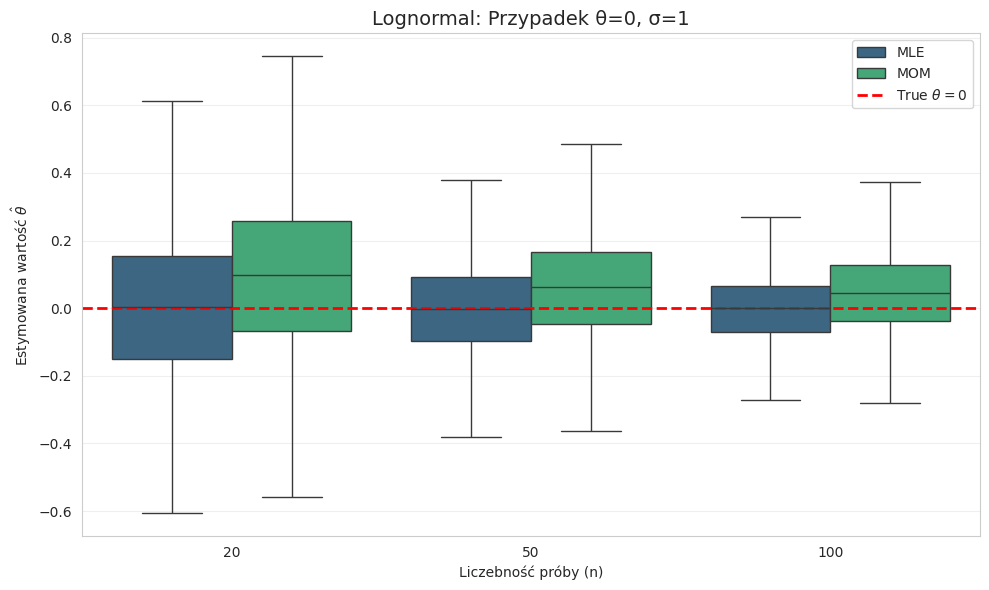

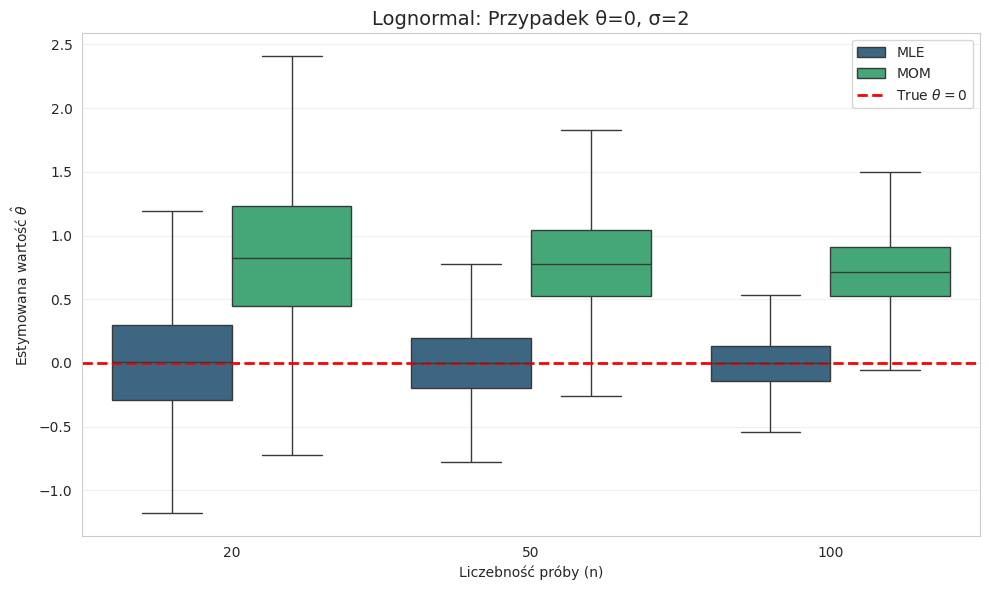

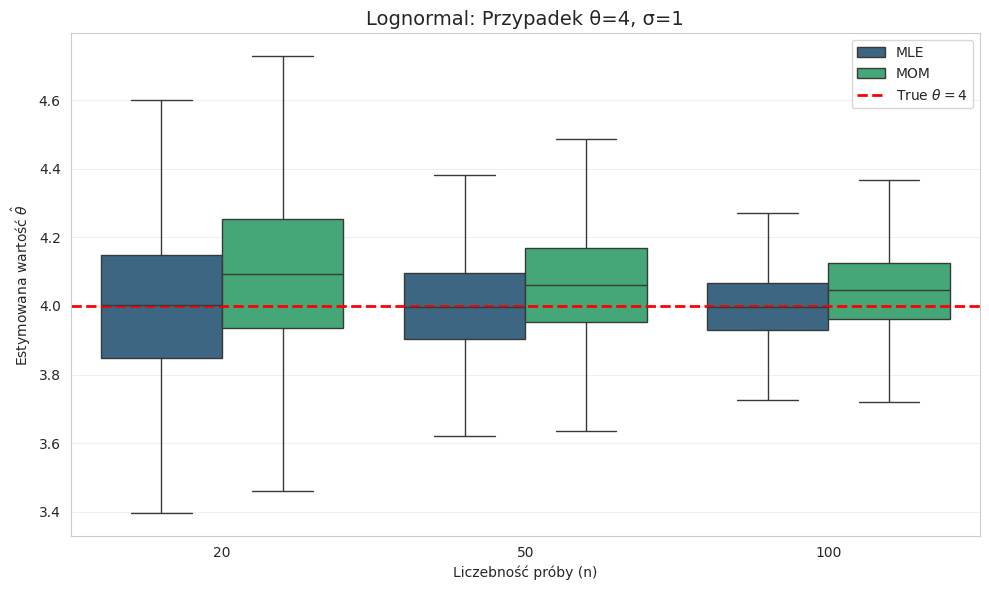

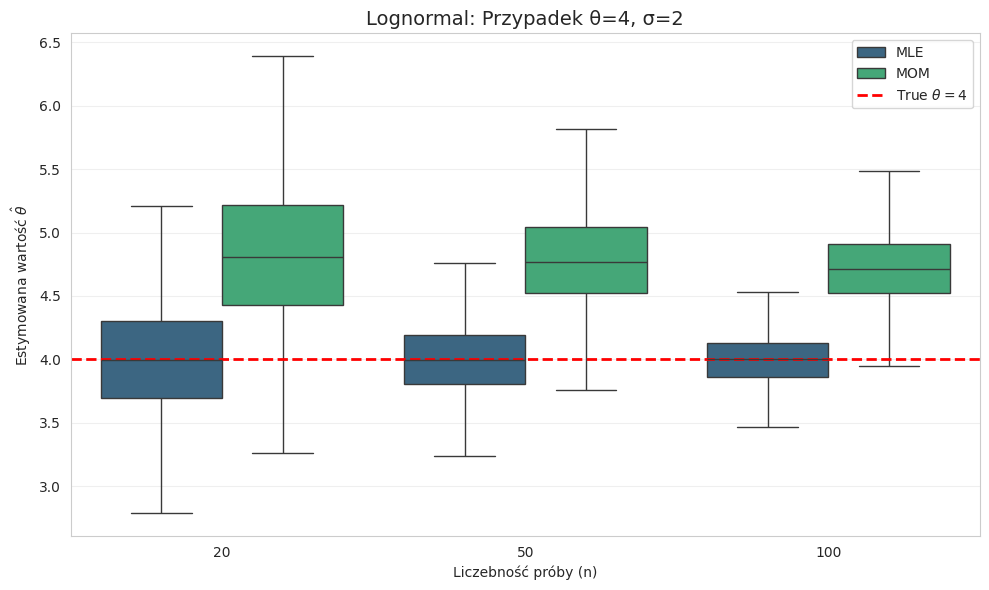

In [46]:
# Generowanie osobnego wykresu dla każdego przypadku (Case)
unique_cases = df_raw_log['Case'].unique()

# Sortujemy, żeby mieć porządek (a) -> (d)
unique_cases.sort()

for case in unique_cases:
    plt.figure(figsize=(10, 6))

    subset = df_raw_log[df_raw_log['Case'] == case]

    # Pobieramy prawdziwe theta z ramki danych (pierwszy rekord dla danego case)
    true_theta = subset['theta'].iloc[0]

    sns.boxplot(x="n", y="Value", hue="Method", data=subset,
                palette="viridis", showfliers=False)

    plt.axhline(true_theta, color='red', linestyle='--', linewidth=2, label=f'True $\\theta={true_theta}$')

    plt.title(f'Lognormal: Przypadek {case}', fontsize=14)
    plt.ylabel('Estymowana wartość $\\hat{\\theta}$')
    plt.xlabel('Liczebność próby (n)')
    plt.legend(loc='upper right')
    plt.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()